# Shear, Moment, and Deflection Diagrams

The most basic form of a line-girder tool — **no Rhino, no MIDAS, nothing to
model**. Pick the bridge settings from the dropdowns (barrier type, AASHTO
vehicle, deck thickness, number of spans, girder size/spacing, …), and the
tool

1. prints the **loads it associated with each selection** — klf per girder
   plus the AASHTO live-load distribution factors, and
2. draws **shear, moment, and deflection diagrams for an interior and an
   exterior girder** — dead load exactly, live load as a stepped-vehicle /
   patterned-lane envelope.

Everything runs on `civilpy.structural.line_girder_tool` +
`continuous_beam.ContinuousBeam`. The solver and the moving-load envelopes are
verified against the **AISC Steel Construction Manual Table 3-23** beam cases
(1, 29, 30, 43, 44) in `tests/structural/test_line_girder_tool.py` and
`tests/structural/test_beam_bending.py`; a spot-check table is at the bottom
of this notebook.

Simplifications (kept loud on purpose — see the module docstring): equal
spans, prismatic bare-steel section for deflection, barriers shared equally by
all girders, single-truck negative moment.

In [1]:
import matplotlib.pyplot as plt

from civilpy.structural.line_girder_tool import (
    BARRIER_CHOICES, VEHICLES, BridgeConfig,
    analyze, loads_table, plot_diagrams,
)

GIRDER_CHOICES = ["W21X68", "W24X84", "W24X104", "W27X114",
                  "W30X132", "W33X141", "W36X160"]

## The tool — pick your settings

Change any dropdown and the loads table + diagrams refresh (live kernel
required; static preset runs follow below). Gray curves are dead load alone,
the colored band is dead + live-load envelope, and the dotted line on the
deflection plot is the L/800 guide.

In [2]:
import ipywidgets as w
from IPython.display import display

controls = dict(
    barrier=w.Dropdown(options=BARRIER_CHOICES, value="SBR-1 (42 in)",
                       description="Barrier Type"),
    vehicle=w.Dropdown(options=list(VEHICLES),
                       value="HL-93 (governing of truck/tandem + lane)",
                       description="AASHTO Vehicle"),
    deck_t_in=w.Dropdown(options=[8.0, 8.5, 9.0, 9.5, 10.0], value=8.5,
                         description="Deck Thickness (in)"),
    n_spans=w.Dropdown(options=[1, 2, 3, 4], value=3,
                       description="Number of Spans"),
    span_ft=w.Dropdown(options=[30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0,
                                100.0, 120.0], value=50.0,
                       description="Span Length (ft)"),
    girder=w.Dropdown(options=GIRDER_CHOICES, value="W24X104",
                      description="Girder"),
    n_girders=w.Dropdown(options=[4, 5, 6, 7, 8], value=5,
                         description="Number of Girders"),
    spacing_ft=w.Dropdown(options=[6.0, 7.0, 8.0, 9.0, 10.0], value=7.0,
                          description="Girder Spacing (ft)"),
    overhang_ft=w.Dropdown(options=[1.5, 2.0, 2.5, 3.0, 3.5], value=2.5,
                           description="Deck Overhang (ft)"),
    fws_ksf=w.Dropdown(options=[0.0, 0.030, 0.060], value=0.060,
                       description="Wearing Surf. (ksf)"),
)
for c in controls.values():
    c.style = {"description_width": "150px"}
    c.layout = w.Layout(width="330px")


def run_tool(**settings):
    result = analyze(BridgeConfig(**settings))
    display(loads_table(result))
    plot_diagrams(result)
    plt.show()


out = w.interactive_output(run_tool, controls)
display(w.HBox([w.VBox(list(controls.values())[:5]),
                w.VBox(list(controls.values())[5:])]), out)

Output()

## A few configurations, rendered statically

The same tool run on three different setups, so the outputs are visible
without a live kernel (and so a change in the library shows up in `git diff`
as a change in these numbers).

**Configuration 1 — single span, HS20-44.** One 40 ft simple span, W24X84 at
8 ft, 36 in BR-1 railing, Standard-Spec truck (impact `50/(L+125)`, no lane
load). The dead-load moment is the hand answer `wL²/8`, and the live-load
moment envelope is the classic single-span truck curve.

,interior,exterior
tributary width (ft),8.000,6.000
"girder self weight, W24X84 (klf)",0.084,0.084
"deck, 8 in slab (klf)",0.800,0.600
DC1 = girder + deck (klf),0.884,0.684
"DC2 = barrier share, BR-1 (36 in) (klf)",0.176,0.176
"DW = wearing surface, 0.03 ksf (klf)",0.240,0.180
total dead load (klf),1.300,1.040
LL distribution factor - moment,0.657,0.542
LL distribution factor - shear,0.814,0.529
LL distribution factor - deflection,0.400,0.400


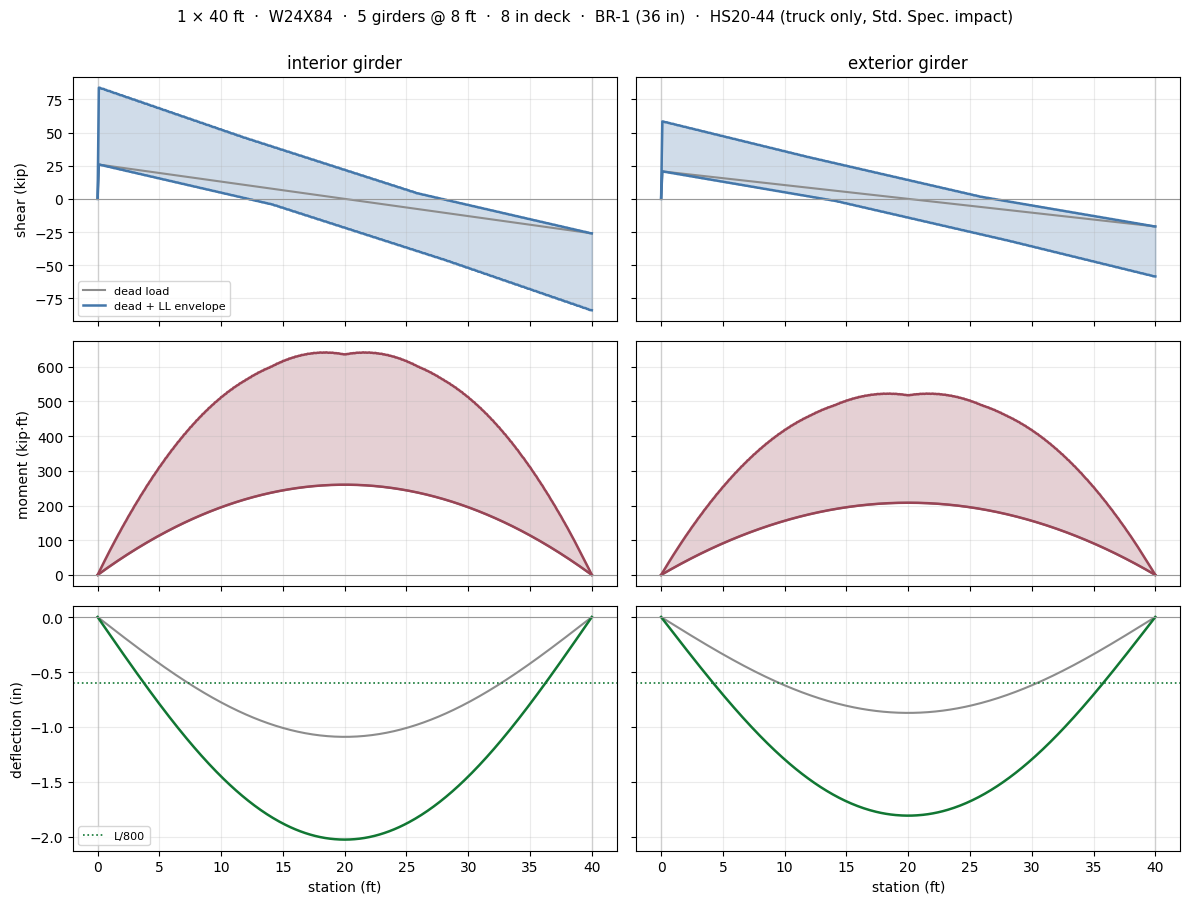

In [3]:
result1 = analyze(BridgeConfig(
    n_spans=1, span_ft=40.0, girder="W24X84", n_girders=5, spacing_ft=8.0,
    overhang_ft=2.0, deck_t_in=8.0, barrier="BR-1 (36 in)",
    vehicle="HS20-44 (truck only, Std. Spec. impact)", fws_ksf=0.030))
display(loads_table(result1))
plot_diagrams(result1)
plt.show()

**Configuration 2 — three equal spans, HL-93.** The 3 × 50 ft, five-girder
arrangement (the old "toy example" of this notebook, now with the full load
build-up). The dead-load diagram hits the AISC Case 30 coefficients exactly:
end reactions `0.4wL`, interior `1.1wL`, `−0.100wL²` over the piers,
`+0.080wL²` in the end spans.

,interior,exterior
tributary width (ft),7.000,6.000
"girder self weight, W24X104 (klf)",0.104,0.104
"deck, 8.5 in slab (klf)",0.744,0.638
DC1 = girder + deck (klf),0.848,0.741
"DC2 = barrier share, SBR-1 (42 in) (klf)",0.245,0.245
"DW = wearing surface, 0.06 ksf (klf)",0.420,0.360
total dead load (klf),1.513,1.346
LL distribution factor - moment,0.567,0.514
LL distribution factor - shear,0.743,0.520
LL distribution factor - deflection,0.400,0.400


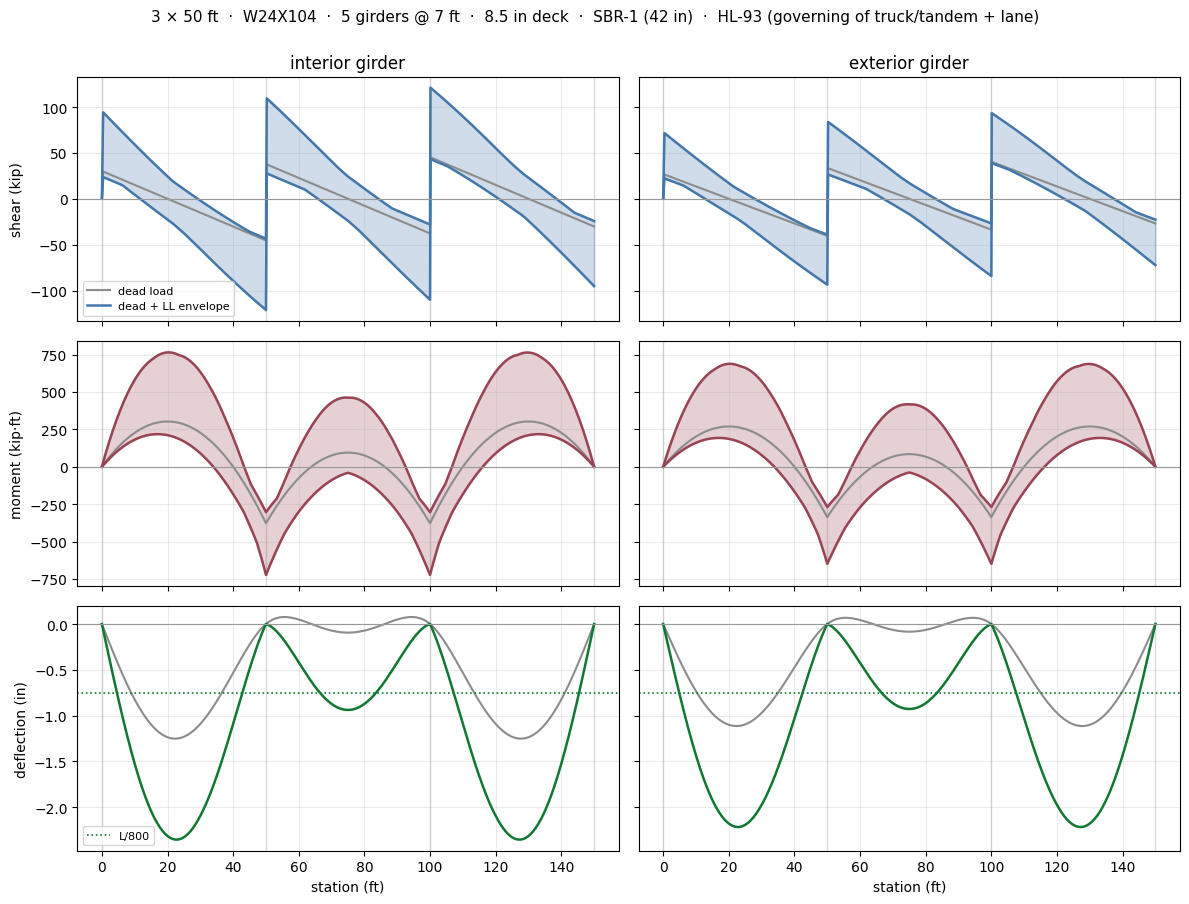

dead-load check vs AISC Case 30 (w = 1.513 klf, L = 50 ft):
  max +M =   302.5 kip·ft   0.080wL² =   302.5
  min −M =  -378.2 kip·ft  −0.100wL² =  -378.2


In [4]:
result2 = analyze(BridgeConfig(
    n_spans=3, span_ft=50.0, girder="W24X104", n_girders=5, spacing_ft=7.0,
    overhang_ft=2.5, deck_t_in=8.5, barrier="SBR-1 (42 in)",
    vehicle="HL-93 (governing of truck/tandem + lane)", fws_ksf=0.060))
display(loads_table(result2))
plot_diagrams(result2)
plt.show()

g = result2.girders["interior"]
w_d = g.loads.dead_total_klf
print(f"dead-load check vs AISC Case 30 (w = {w_d:.3f} klf, L = 50 ft):")
print(f"  max +M = {max(g.m_dead):7.1f} kip·ft   0.080wL² = {0.080*w_d*50**2:7.1f}")
print(f"  min −M = {min(g.m_dead):7.1f} kip·ft  −0.100wL² = {-0.100*w_d*50**2:7.1f}")

**Configuration 3 — two long spans, design tandem.** 2 × 90 ft on a deeper
W36X160 at 9 ft with the 57 in median-barrier section — the tandem + lane
governs short/medium spans' positive regions less often, so compare this
against configuration 2's truck-governed envelope.

,interior,exterior
tributary width (ft),9.000,7.500
"girder self weight, W36X160 (klf)",0.160,0.160
"deck, 9 in slab (klf)",1.012,0.844
DC1 = girder + deck (klf),1.172,1.004
"DC2 = barrier share, SBR-2 (57 in median) (klf)",0.453,0.453
"DW = wearing surface, 0.06 ksf (klf)",0.540,0.450
total dead load (klf),2.165,1.906
LL distribution factor - moment,0.627,0.558
LL distribution factor - shear,0.884,0.558
LL distribution factor - deflection,0.425,0.425


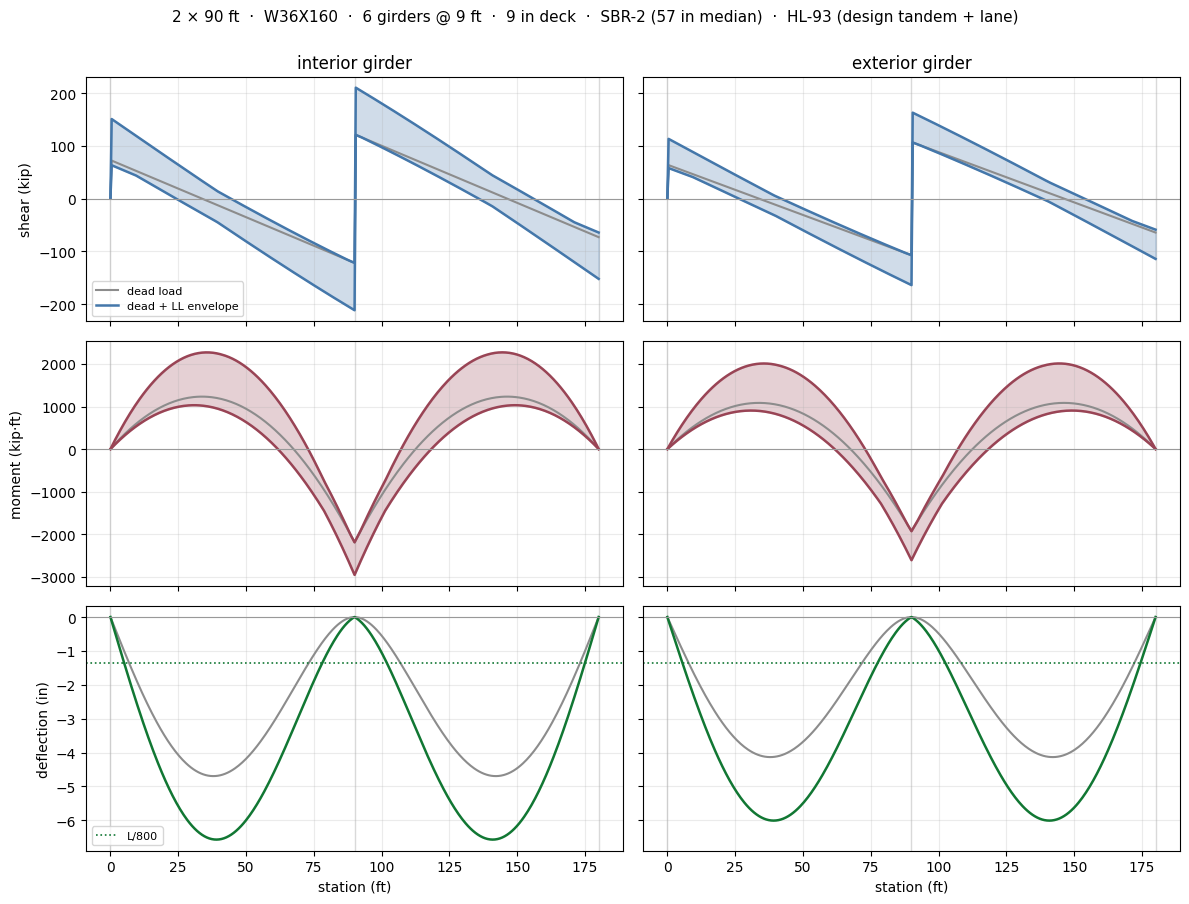

In [5]:
result3 = analyze(BridgeConfig(
    n_spans=2, span_ft=90.0, girder="W36X160", n_girders=6, spacing_ft=9.0,
    overhang_ft=3.0, deck_t_in=9.0, barrier="SBR-2 (57 in median)",
    vehicle="HL-93 (design tandem + lane)", fws_ksf=0.060))
display(loads_table(result3))
plot_diagrams(result3)
plt.show()

## Verification against AISC Table 3-23

The full check lives in `tests/structural/test_line_girder_tool.py` (and the
symbolic solver's own AISC cases in `tests/structural/test_beam_bending.py`);
this cell reruns the headline numbers so the comparison is visible here.
`w = 1 klf`, `L = 20 ft`, `P = 10 kip` throughout.

In [6]:
import numpy as np
import pandas as pd

from civilpy.structural.continuous_beam import ContinuousBeam
from civilpy.structural.line_girder_tool import moving_load_envelope

L, w_u, P, E, I = 20.0, 1.0, 10.0, 29000.0, 100.0
rows = []

b1 = ContinuousBeam([0, L]).add_udl(w_u)
_, d1 = b1.deflection_diagram(E, I, n=2001)
rows += [("Case 1: simple span, M = wL²/8", max(b1.moment_diagram(2001)[1]),
          w_u * L**2 / 8),
         ("Case 1: Δ = 5wL⁴/384EI (in)", -min(d1),
          5 * (w_u / 12) * (L * 12)**4 / (384 * E * I))]

b29 = ContinuousBeam([0, L, 2 * L]).add_udl(w_u)
_, v29, m29 = b29.diagrams(n=4001)
_, d29 = b29.deflection_diagram(E, I, n=4001)
rows += [("Case 29: two spans, R2 = 1.25wL", b29.reactions()[1], 1.25 * w_u * L),
         ("Case 29: V = 0.625wL", max(abs(v29)), 0.625 * w_u * L),
         ("Case 29: M = −wL²/8", min(m29), -w_u * L**2 / 8),
         ("Case 29: Δ = wL⁴/185EI (in)", -min(d29),
          (w_u / 12) * (L * 12)**4 / (185 * E * I))]

b30 = ContinuousBeam([0, L, 2 * L, 3 * L]).add_udl(w_u)
_, _, m30 = b30.diagrams(n=6001)
_, d30 = b30.deflection_diagram(E, I, n=6001)
rows += [("Case 30: three spans, R1 = 0.4wL", b30.reactions()[0], 0.4 * w_u * L),
         ("Case 30: M = −0.100wL²", min(m30), -0.100 * w_u * L**2),
         ("Case 30: M = +0.080wL²", max(m30), 0.080 * w_u * L**2),
         ("Case 30: Δ = 0.0069wL⁴/EI (in)", -min(d30),
          0.0069 * (w_u / 12) * (L * 12)**4 / (E * I))]

e43 = moving_load_envelope([0, L], [([P], [0.0])], n=801, step=0.05)
e44 = moving_load_envelope([0, L], [([P, P], [0.0, 5.0])], n=801, step=0.05)
rows += [("Case 43: moving load, M = PL/4", max(e43["m_max"]), P * L / 4),
         ("Case 44: two moving loads, M = (P/2L)(L−a/2)²",
          max(e44["m_max"]), P / (2 * L) * (L - 5.0 / 2)**2)]

table = pd.DataFrame(rows, columns=["AISC Table 3-23 case", "civilpy", "AISC"])
table["ratio"] = table.civilpy / table.AISC
table.round(4)

,AISC Table 3-23 case,civilpy,AISC,ratio
0,"Case 1: simple span, M = wL²/8",50.0000,50.0000,1.0000
1,Case 1: Δ = 5wL⁴/384EI (in),1.2414,1.2414,1.0000
2,"Case 29: two spans, R2 = 1.25wL",25.0000,25.0000,1.0000
3,Case 29: V = 0.625wL,12.5000,12.5000,1.0000
4,Case 29: M = −wL²/8,-50.0000,-50.0000,1.0000
5,Case 29: Δ = wL⁴/185EI (in),0.5164,0.5153,1.0020
6,"Case 30: three spans, R1 = 0.4wL",8.0000,8.0000,1.0000
7,Case 30: M = −0.100wL²,-40.0000,-40.0000,1.0000
8,Case 30: M = +0.080wL²,32.0000,32.0000,1.0000
9,Case 30: Δ = 0.0069wL⁴/EI (in),0.6563,0.6578,0.9977
